# Inference and generalisation

Two things here. First, check that `predict_bytes` works, since the API is just
a thin wrapper around it and a plain function is far easier to debug than one
inside a running server.

Second, run the model on images it was never evaluated on, from other subsets of
the dataset and from the open internet, to find where it breaks outside its own
test set.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import torch
import matplotlib.pyplot as plt
from pathlib import Path

from src.predict import load_model, predict_bytes

SEG = Path("../data/segmentation")
DATA_EXT = Path("../data/external")
MODEL_PATH = "../models/best_model.pth"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = load_model(MODEL_PATH, device)

print("model loaded on", device)

model loaded on mps


## 1. Sanity check on known images

One image known to contain fish and one known to be empty. If these are wrong,
nothing below is worth reading.

In [2]:
def run(path, show=False):
    """Run the model on an image file and optionally display the mask."""
    with open(path, "rb") as f:
        result = predict_bytes(model, f.read(), device, return_mask=show)

    if show:
        _, ax = plt.subplots(1, 2, figsize=(14, 4))
        ax[0].imshow(result["_image"])
        ax[0].set_title(Path(path).name, fontsize=9)
        ax[1].imshow(result["_mask"], cmap="gray")
        ax[1].set_title(f"{result['fish_coverage_percent']}% coverage")
        for a in ax:
            a.axis("off")
        plt.tight_layout()
        plt.show()

    # Drop the display-only keys so the printed result matches an API response.
    return {k: v for k, v in result.items() if not k.startswith("_")}


fish_image = SEG / "images" / "valid" / "9862_Acanthopagrus_palmaris_f000090.jpg"
empty_image = SEG / "images" / "empty" / "7398_NF2_f000160.jpg"

print("fish image :", run(fish_image))
print("empty image:", run(empty_image))

fish image : {'fish_detected': True, 'fish_pixels': 7597, 'fish_coverage_percent': 6.624, 'mean_confidence': 0.956, 'original_size': [1920, 1080], 'inference_ms': 471.9}
empty image: {'fish_detected': False, 'fish_pixels': 0, 'fish_coverage_percent': 0.0, 'mean_confidence': None, 'original_size': [1920, 1080], 'inference_ms': 97.2}


## 2. External images

None of these were used in training, validation, or the test set. They come from
the classification and localization subsets of DeepFish, plus a few underwater
images from the internet with different cameras and habitats.

The point is not to score them. There are no ground truth masks. The point is to
see what the model does when conditions drift away from what it was trained on.

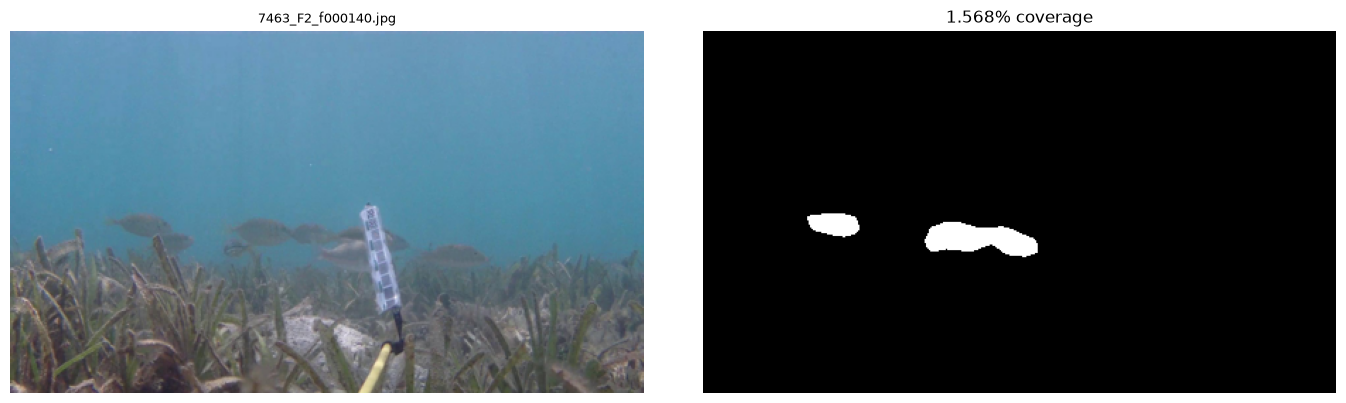

{'fish_detected': True, 'fish_pixels': 1798, 'fish_coverage_percent': 1.568, 'mean_confidence': 0.809, 'original_size': [1920, 1080], 'inference_ms': 104.3}


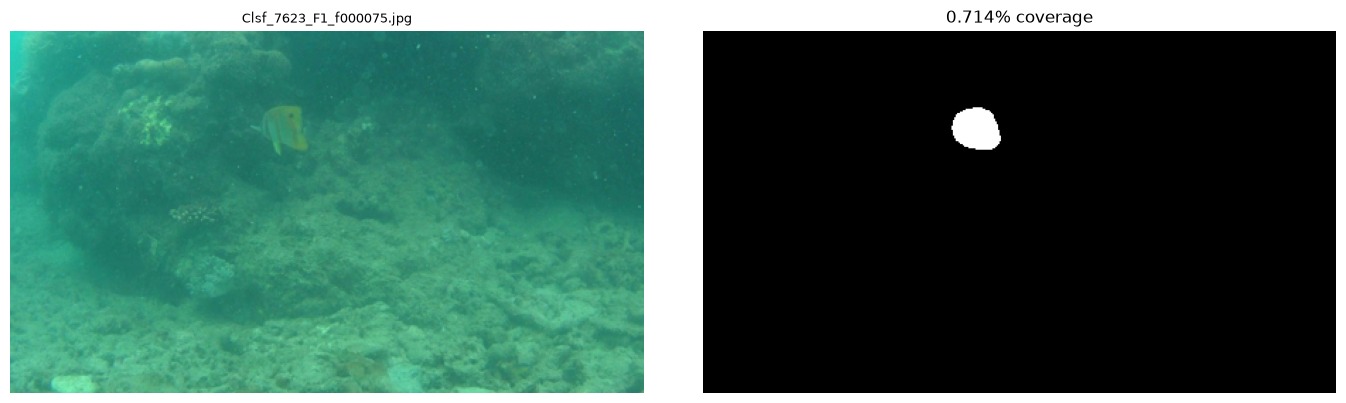

{'fish_detected': True, 'fish_pixels': 819, 'fish_coverage_percent': 0.714, 'mean_confidence': 0.904, 'original_size': [1920, 1080], 'inference_ms': 105.6}


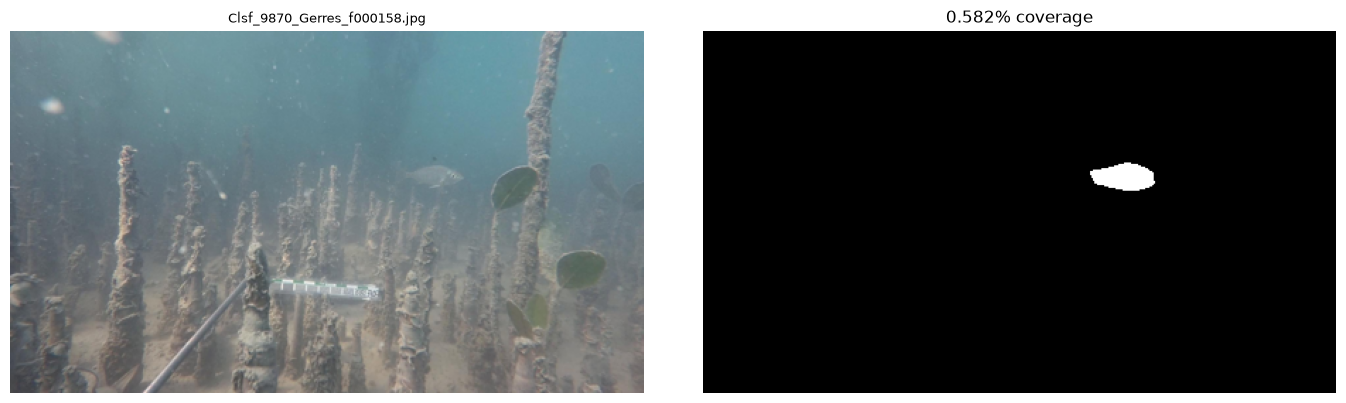

{'fish_detected': True, 'fish_pixels': 667, 'fish_coverage_percent': 0.582, 'mean_confidence': 0.894, 'original_size': [1920, 1080], 'inference_ms': 104.0}


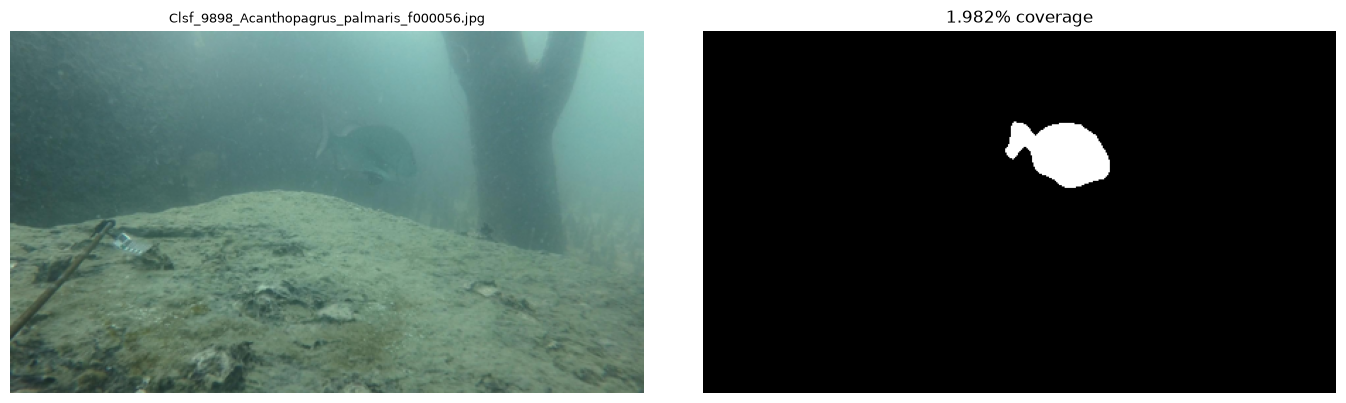

{'fish_detected': True, 'fish_pixels': 2273, 'fish_coverage_percent': 1.982, 'mean_confidence': 0.902, 'original_size': [1920, 1080], 'inference_ms': 105.2}


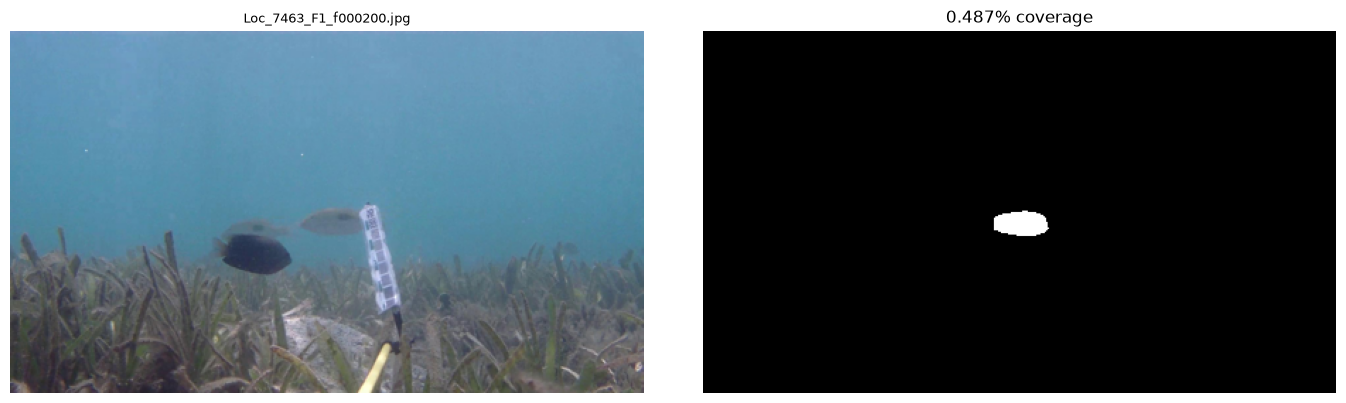

{'fish_detected': True, 'fish_pixels': 558, 'fish_coverage_percent': 0.487, 'mean_confidence': 0.845, 'original_size': [1920, 1080], 'inference_ms': 96.7}


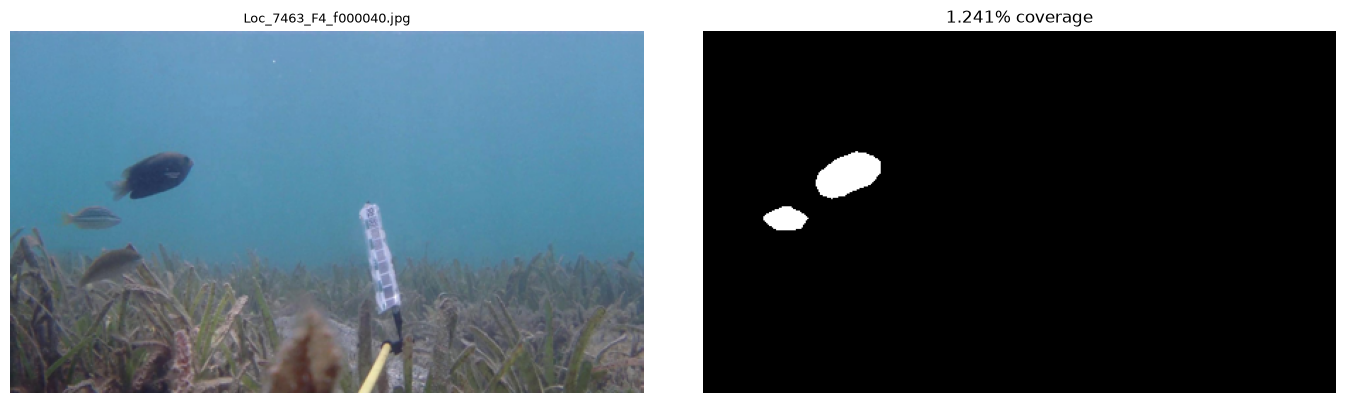

{'fish_detected': True, 'fish_pixels': 1423, 'fish_coverage_percent': 1.241, 'mean_confidence': 0.857, 'original_size': [1920, 1080], 'inference_ms': 99.0}


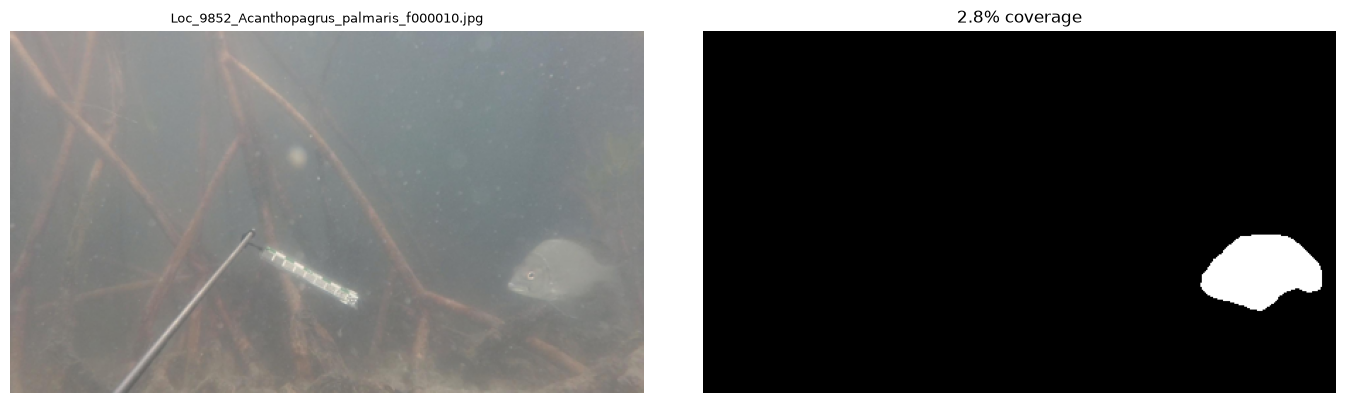

{'fish_detected': True, 'fish_pixels': 3211, 'fish_coverage_percent': 2.8, 'mean_confidence': 0.938, 'original_size': [1920, 1080], 'inference_ms': 97.3}


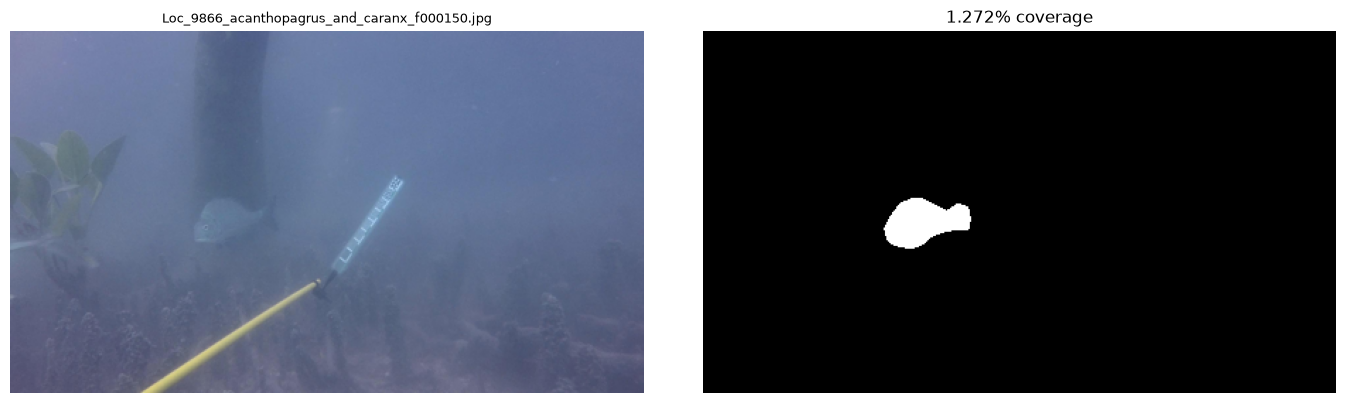

{'fish_detected': True, 'fish_pixels': 1459, 'fish_coverage_percent': 1.272, 'mean_confidence': 0.917, 'original_size': [1920, 1080], 'inference_ms': 112.0}


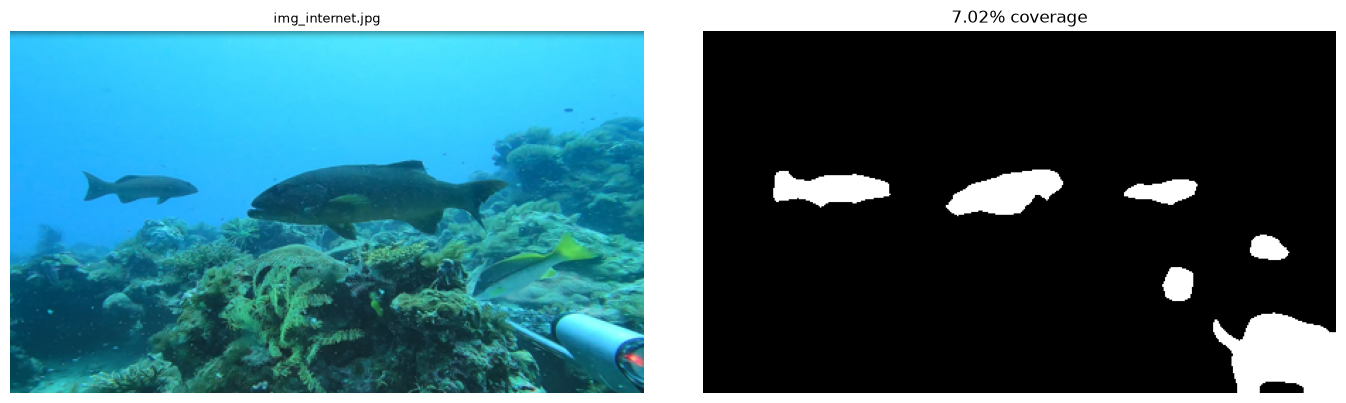

{'fish_detected': True, 'fish_pixels': 8051, 'fish_coverage_percent': 7.02, 'mean_confidence': 0.845, 'original_size': [1280, 853], 'inference_ms': 101.5}


In [3]:
external = sorted(DATA_EXT.glob("*.jpg"))

for path in external:
    result = run(path, show=True)
    print(result)

## Where the model fails

Observations from the images from dataset and from wider manual testing on other
DeepFish subsets. These are not bugs to fix. With 310 training images from a
handful of Australian habitats, they are limits of the training data, and
knowing them is more useful than hiding them.

**Small fish.** Sometimes missed entirely, though many small fish are segmented
well. Consistent with the test set finding that below roughly 2 percent of frame
the model becomes unreliable rather than uniformly worse.

**Camouflaged species.** Grey *Gerres* against sandy substrate is caught in some
frames and missed in others. The same species produced the zero scores in
evaluation.

**Groups of fish.** Two separate things happen here. Overlapping fish merge into
a single region, because this is semantic segmentation, fish against background,
with no concept of an individual fish. Separately, when fish move in a group,
some are left out of the mask altogether. Counting individuals would need
instance segmentation, which is a different model.

**Unseen species.** A dark fish absent from the training habitats is detected in
some frames and missed in others. The model learned what fish look like in this
dataset, which is all 310 images can teach it.

**Different camera and habitat.** On internet images with different optics,
colour balance, and water clarity, the model still finds fish but often only
some of them, and outlines them incompletely. This is domain shift and it is the
failure mode most likely to matter in deployment.

**Equipment mistaken for fish.** On one external image the model segments
underwater equipment as fish. Worth separating from the misses above, since this
is a false positive, and the only one observed anywhere. On the 90 empty test
images the model produced no false positives at all, so this appears specific to
objects that were not present in the training habitats.

**Inference time.** Around 100 ms per image on Apple Silicon (mps). The API runs
on CPU, where the same call takes 170 to 220 ms.